In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [5]:
# --- 1. Load data
data = fetch_california_housing(as_frame=True)
x, y = data.data, data.target

In [43]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [45]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [6]:
# --- 2. Split BEFORE scaling (avoid leakage!)
x_train , x_test , y_train , y_test = train_test_split(x,y , test_size = 0.2 , random_state = 42)

In [7]:
# --- 3. Scale features (fit only on train, transform both)
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

In [8]:
# --- 4. Baseline: plain Linear Regression
lr = LinearRegression()
lr.fit(x_train_s , y_train)
print("Linear Regression")
print(f" Train R2: {lr.score(x_train_s , y_train):.4f}")
print(f" Train R2: {lr.score(x_test_s , y_test):.4f}")

Linear Regression
 Train R2: 0.6126
 Train R2: 0.5758


In [9]:
# --- 5. Ridge with manual alpha
ridge = Ridge(alpha=1.0)
ridge.fit(x_train_s, y_train)
print("\nRIDGE (alpha=1.0)")
print(f"  Train R²: {ridge.score(x_train_s, y_train):.4f}")
print(f"  Test  R²: {ridge.score(x_test_s,  y_test):.4f}")


RIDGE (alpha=1.0)
  Train R²: 0.6126
  Test  R²: 0.5758


In [10]:
# --- 6. Ridge with auto alpha tuning (RidgeCV)
alphas = [0.001,0.01,0.1,1,10,100,1000]
ridge_cv = RidgeCV(alphas = alphas , cv=5 , scoring = 'r2')
ridge_cv.fit(x_train_s, y_train)
print(f"\nRidgeCV best alpha: {ridge_cv.alpha_}")
print(f"  Train R2: {ridge_cv.score(x_train_s,y_train):.4f}")
print(f"  Train R2: {ridge_cv.score(x_test_s,y_test):.4f}")


RidgeCV best alpha: 0.001
  Train R2: 0.6126
  Train R2: 0.5758


In [12]:
# --- 7. Cross validation score
cv_scores = cross_val_score(
    Ridge(alpha=ridge_cv.alpha_),
    x_train_s, y_train,
    cv=5, scoring='neg_mean_squared_error'
)
print(f"\nCV neg-MSE: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"CV RMSE   : {np.sqrt(-cv_scores.mean()):.4f}")


CV neg-MSE: -0.5193 ± 0.0149
CV RMSE   : 0.7206


In [13]:
# --- 8. Inspect coefficients
coef_df = pd.DataFrame({
    'feature': x.columns,
    'linear_coef': lr.coef_,
    'ridge_coef':  ridge_cv.coef_
}).sort_values('ridge_coef', ascending=False)
print("\nCoefficient comparison:")
print(coef_df.to_string(index=False))


Coefficient comparison:
   feature  linear_coef  ridge_coef
    MedInc     0.854383    0.854383
 AveBedrms     0.339259    0.339259
  HouseAge     0.122546    0.122546
Population    -0.002308   -0.002308
  AveOccup    -0.040829   -0.040829
  AveRooms    -0.294410   -0.294410
 Longitude    -0.869842   -0.869841
  Latitude    -0.896929   -0.896928


Lasso implementation

In [14]:
from sklearn.linear_model import Lasso, LassoCV

# --- Lasso with LassoCV for auto alpha tuning
lasso_cv = LassoCV(
    alphas=np.logspace(-4, 2, 100),  # 100 values from 0.0001 to 100
    cv=5,
    random_state=42,
    max_iter=10000       # increase if ConvergenceWarning appears
)
lasso_cv.fit(x_train_s, y_train)

LassoCV(alphas=array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
       1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
       3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
       5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
       9.32603347e-04, 1.07226722e-03, 1.23284674e-03, 1.41747416e-03,
       1.62975083e-03, 1.87381742e-0...
       4.03701726e+00, 4.64158883e+00, 5.33669923e+00, 6.13590727e+00,
       7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
       1.23284674e+01, 1.41747416e+01, 1.62975083e+01, 1.87381742e+01,
       2.15443469e+01, 2.47707636e+01, 2.84803587e+01, 3.27454916e+01,
       3.76493581e+01, 4.32876128e+01, 4.97702356e+01, 5.72236766e+01,
       6.57933225e+01, 7.56463328e+01, 8.69749003e+01, 1.00000000e+02]),
        cv=5, max_iter=10000, random_state=42)

In [15]:
print(f"Lasso best alpha: {lasso_cv.alpha_:.5f}")
print(f"Train R²: {lasso_cv.score(x_train_s, y_train):.4f}")
print(f"Test  R²: {lasso_cv.score(x_test_s,  y_test):.4f}")

Lasso best alpha: 0.00071
Train R²: 0.6125
Test  R²: 0.5766


In [17]:
# --- Feature selection: which coefficients are zero?
coef_df = pd.DataFrame({
    'feature': x.columns,
    'lasso_coef': lasso_cv.coef_
}).sort_values('lasso_coef', key=abs, ascending=False)

zero_features = coef_df[coef_df['lasso_coef'] == 0]['feature'].tolist()
kept_features = coef_df[coef_df['lasso_coef'] != 0]['feature'].tolist()
print(f"\nFeatures KEPT ({len(kept_features)}): {kept_features}")
print(f"Features ZEROED ({len(zero_features)}): {zero_features}")


Features KEPT (8): ['Latitude', 'Longitude', 'MedInc', 'AveBedrms', 'AveRooms', 'HouseAge', 'AveOccup', 'Population']
Features ZEROED (0): []


ElasticNet implementation

In [18]:
from sklearn.linear_model import ElasticNet, ElasticNetCV

# --- ElasticNetCV: tunes both alpha and l1_ratio simultaneously
en_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
    alphas=np.logspace(-4, 2, 50),
    cv=5,
    random_state=42,
    max_iter=10000
)
en_cv.fit(x_train_s, y_train)

ElasticNetCV(alphas=array([1.00000000e-04, 1.32571137e-04, 1.75751062e-04, 2.32995181e-04,
       3.08884360e-04, 4.09491506e-04, 5.42867544e-04, 7.19685673e-04,
       9.54095476e-04, 1.26485522e-03, 1.67683294e-03, 2.22299648e-03,
       2.94705170e-03, 3.90693994e-03, 5.17947468e-03, 6.86648845e-03,
       9.10298178e-03, 1.20679264e-02, 1.59985872e-02, 2.12095089e-02,
       2.81176870e-02, 3.727593...
       2.68269580e-01, 3.55648031e-01, 4.71486636e-01, 6.25055193e-01,
       8.28642773e-01, 1.09854114e+00, 1.45634848e+00, 1.93069773e+00,
       2.55954792e+00, 3.39322177e+00, 4.49843267e+00, 5.96362332e+00,
       7.90604321e+00, 1.04811313e+01, 1.38949549e+01, 1.84206997e+01,
       2.44205309e+01, 3.23745754e+01, 4.29193426e+01, 5.68986603e+01,
       7.54312006e+01, 1.00000000e+02]),
             cv=5, l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
             max_iter=10000, random_state=42)

In [33]:
elastic_pred = en_cv.predict(x_test_s)

In [19]:
print(f"Best alpha   : {en_cv.alpha_:.5f}")
print(f"Best l1_ratio: {en_cv.l1_ratio_:.2f}")
print(f"Train R²: {en_cv.score(x_train_s, y_train):.4f}")
print(f"Test  R²: {en_cv.score(x_test_s,  y_test):.4f}")

Best alpha   : 0.00072
Best l1_ratio: 1.00
Train R²: 0.6125
Test  R²: 0.5766


In [20]:
# --- Final comparison: all 4 models side by side
models = {
    'Linear': lr,
    'Ridge':  ridge_cv,
    'Lasso':  lasso_cv,
    'ElasticNet': en_cv
}
print("\n--- MODEL COMPARISON ---")
print(f"{'Model':<12} {'Train R²':>10} {'Test R²':>10} {'Non-zero coefs':>15}")
for name, m in models.items():
    n_nz = np.sum(m.coef_ != 0)
    print(f"{name:<12} {m.score(x_train_s,y_train):>10.4f}"
          f" {m.score(x_test_s,y_test):>10.4f} {n_nz:>15}")


--- MODEL COMPARISON ---
Model          Train R²    Test R²  Non-zero coefs
Linear           0.6126     0.5758               8
Ridge            0.6126     0.5758               8
Lasso            0.6125     0.5766               8
ElasticNet       0.6125     0.5766               8


Text(0.5, 1.0, 'Residuals vs Predicted')

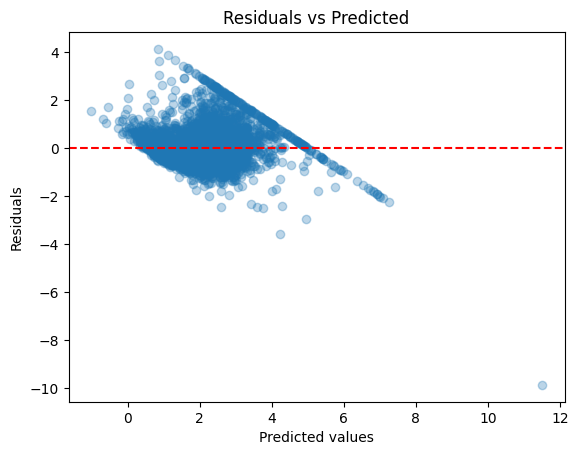

In [35]:
import matplotlib.pyplot as plt

y_pred = ridge_cv.predict(x_test_s)
residuals = y_test - y_pred

# Good model: residuals random around 0
# Bad model: residuals have a pattern
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")

In [21]:
import pandas as pd

df = pd.DataFrame(data.data, columns=data.feature_names)

df["Target"] = data.target

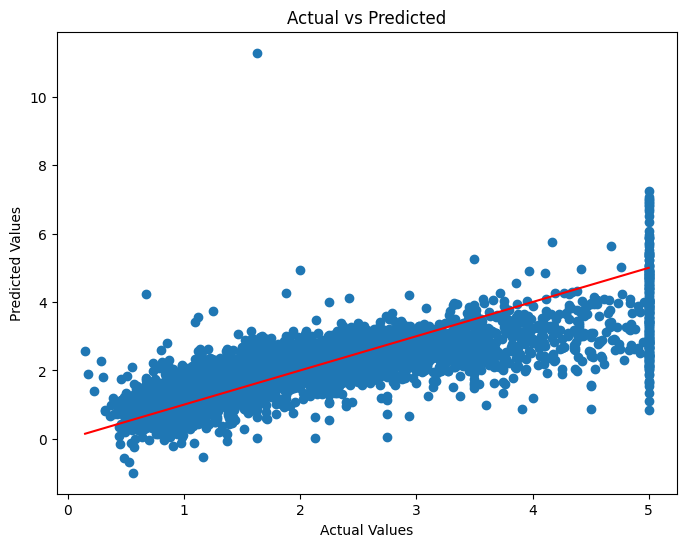

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, elastic_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()

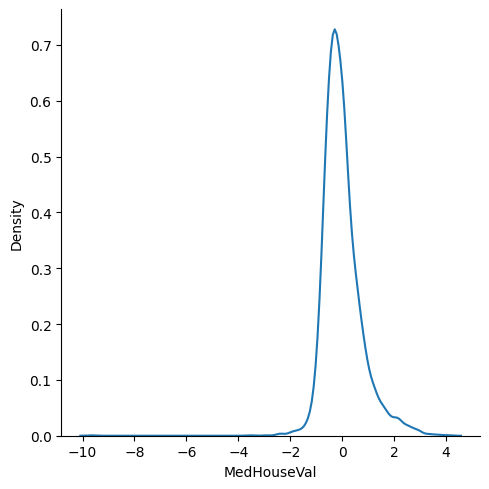

In [37]:
import seaborn as sns 
sns.displot(y_test - elastic_pred , kind='kde')

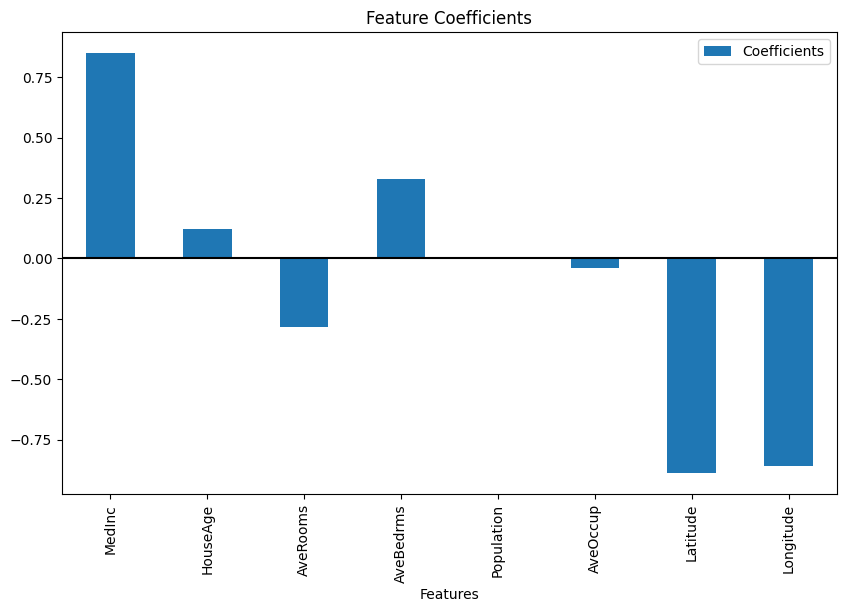

In [38]:
import pandas as pd

coef_df = pd.DataFrame({
    'Features': x.columns,
    'Coefficients': en_cv.coef_
})

coef_df.plot(
    x='Features',
    y='Coefficients',
    kind='bar',
    figsize=(10,6)
)

plt.title("Feature Coefficients")

plt.axhline(y=0, color='black')

plt.show()